In [2]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

In [3]:
df = pd.read_csv('data\Housing.csv')

In [4]:
df.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished


In [5]:
df.describe()

,price,area,bedrooms,bathrooms,stories,parking
count,5.450000e+02,545.000000,545.000000,545.000000,545.000000,545.000000
mean,4.766729e+06,5150.541284,2.965138,1.286239,1.805505,0.693578
std,1.870440e+06,2170.141023,0.738064,0.502470,0.867492,0.861586
min,1.750000e+06,1650.000000,1.000000,1.000000,1.000000,0.000000
25%,3.430000e+06,3600.000000,2.000000,1.000000,1.000000,0.000000
50%,4.340000e+06,4600.000000,3.000000,1.000000,2.000000,0.000000
75%,5.740000e+06,6360.000000,3.000000,2.000000,2.000000,1.000000
max,1.330000e+07,16200.000000,6.000000,4.000000,4.000000,3.000000


In [6]:
df.isnull().sum()

price               0
area                0
bedrooms            0
bathrooms           0
stories             0
mainroad            0
guestroom           0
basement            0
hotwaterheating     0
airconditioning     0
parking             0
prefarea            0
furnishingstatus    0
dtype: int64

In [7]:
df.isnull().sum().sum()

np.int64(0)

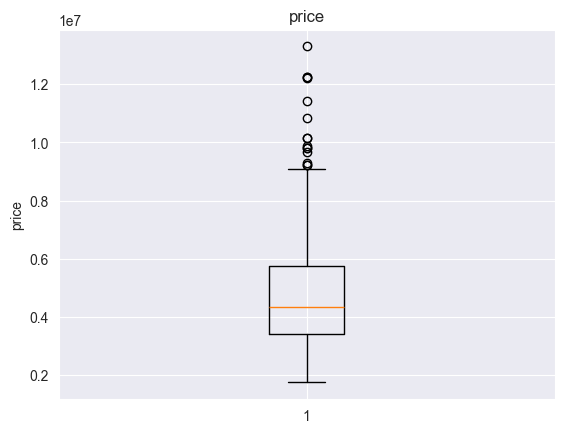

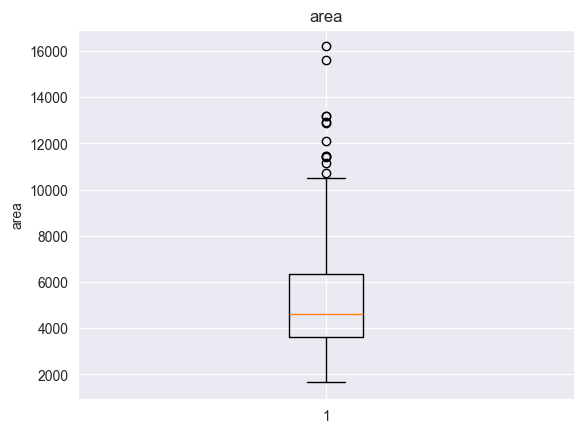

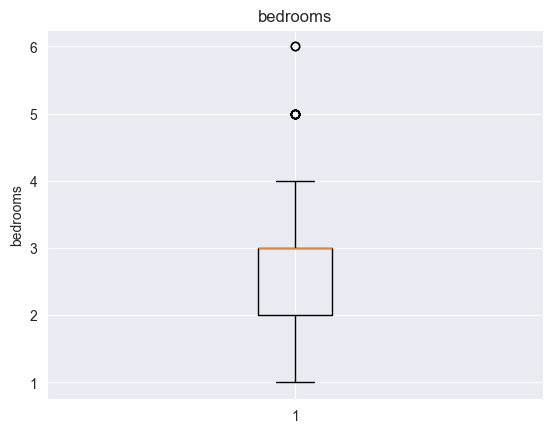

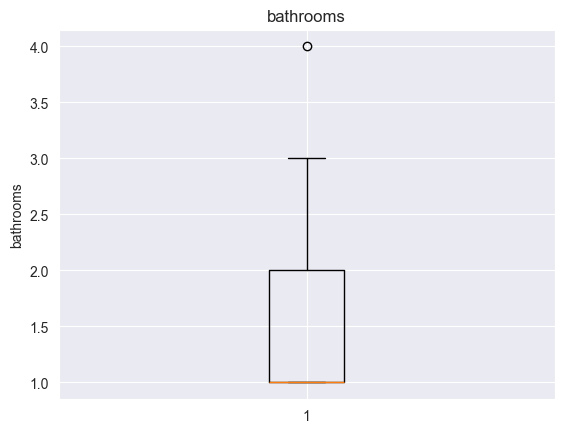

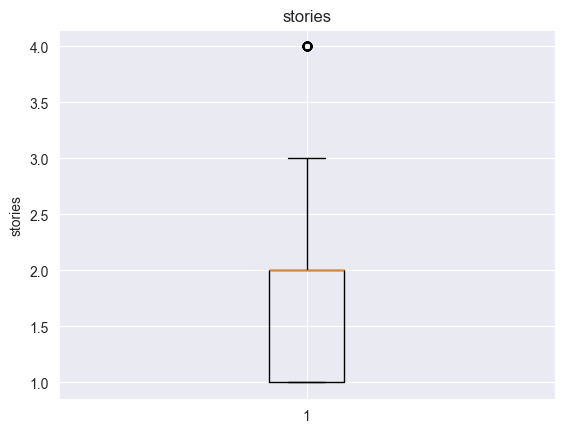

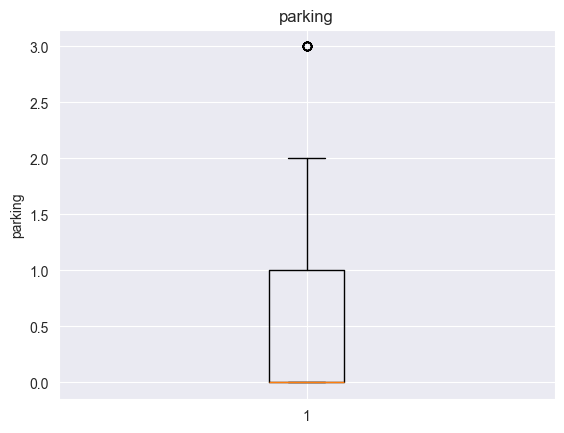

In [8]:
for column in df.select_dtypes(include='number').columns:
    plt.figure()
    plt.boxplot(df[column])
    plt.title(column)
    plt.ylabel(column)
    plt.show()


In [9]:
import plotly.graph_objects as go

fig = go.Figure()

for column in df.select_dtypes(include='number').columns:
    fig.add_trace(
        go.Box(
            y=df[column],
            name=column,
            boxmean='sd'  # shows mean & std
        )
    )

fig.update_layout(
    title="Boxplots of Numeric Columns",
    xaxis_title="Columns",
    yaxis_title="Values"
)

fig.show()


In [10]:
df.dtypes

price                int64
area                 int64
bedrooms             int64
bathrooms            int64
stories              int64
mainroad            object
guestroom           object
basement            object
hotwaterheating     object
airconditioning     object
parking              int64
prefarea            object
furnishingstatus    object
dtype: object

In [12]:

for column in df.select_dtypes(include='object').columns:
    df[column] = df[column].astype('category')
df.dtypes

price                  int64
area                   int64
bedrooms               int64
bathrooms              int64
stories                int64
mainroad            category
guestroom           category
basement            category
hotwaterheating     category
airconditioning     category
parking                int64
prefarea            category
furnishingstatus    category
dtype: object

In [15]:
for column in df.select_dtypes(include='category').columns:
    print(df[column].unique())

['yes', 'no']
Categories (2, object): ['no', 'yes']
['no', 'yes']
Categories (2, object): ['no', 'yes']
['no', 'yes']
Categories (2, object): ['no', 'yes']
['no', 'yes']
Categories (2, object): ['no', 'yes']
['yes', 'no']
Categories (2, object): ['no', 'yes']
['yes', 'no']
Categories (2, object): ['no', 'yes']
['furnished', 'semi-furnished', 'unfurnished']
Categories (3, object): ['furnished', 'semi-furnished', 'unfurnished']


In [16]:
yes_no_cols = ['mainroad', 'guestroom', 'basement', 'hotwaterheating', 'airconditioning', 'prefarea']
for col in yes_no_cols:
    df[col] = df[col].map({'yes': 1, 'no': 0}).astype(int)

In [17]:
df.dtypes

price                  int64
area                   int64
bedrooms               int64
bathrooms              int64
stories                int64
mainroad               int64
guestroom              int64
basement               int64
hotwaterheating        int64
airconditioning        int64
parking                int64
prefarea               int64
furnishingstatus    category
dtype: object

In [18]:
df = pd.get_dummies(df, columns=['furnishingstatus'])

In [19]:
for cols in df.columns:
    print(f"{cols}: {df[cols].dtype}")

price: int64
area: int64
bedrooms: int64
bathrooms: int64
stories: int64
mainroad: int64
guestroom: int64
basement: int64
hotwaterheating: int64
airconditioning: int64
parking: int64
prefarea: int64
furnishingstatus_furnished: bool
furnishingstatus_semi-furnished: bool
furnishingstatus_unfurnished: bool


In [20]:
df.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus_furnished,furnishingstatus_semi-furnished,furnishingstatus_unfurnished
0,13300000,7420,4,2,3,1,0,0,0,1,2,1,True,False,False
1,12250000,8960,4,4,4,1,0,0,0,1,3,0,True,False,False
2,12250000,9960,3,2,2,1,0,1,0,0,2,1,False,True,False
3,12215000,7500,4,2,2,1,0,1,0,1,3,1,True,False,False
4,11410000,7420,4,1,2,1,1,1,0,1,2,0,True,False,False


In [21]:
cols = [c for c in df.columns if c.startswith('furnishingstatus_')]
df[cols] = df[cols].astype(int)

In [22]:
df.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus_furnished,furnishingstatus_semi-furnished,furnishingstatus_unfurnished
0,13300000,7420,4,2,3,1,0,0,0,1,2,1,1,0,0
1,12250000,8960,4,4,4,1,0,0,0,1,3,0,1,0,0
2,12250000,9960,3,2,2,1,0,1,0,0,2,1,0,1,0
3,12215000,7500,4,2,2,1,0,1,0,1,3,1,1,0,0
4,11410000,7420,4,1,2,1,1,1,0,1,2,0,1,0,0


In [23]:
# Features & target
X = df.drop(columns=['price'])
y = df['price']

In [24]:
from sklearn.model_selection import train_test_split
# Train / Test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

In [25]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

# Fit on training data, transform both
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)


In [33]:
import plotly.express as px

X_train_scaled = pd.DataFrame(
    X_train_scaled,
    columns=X_train.columns,
    index=X_train.index
)
corr = X_train_scaled.corr().round(2)

fig = px.imshow(
    corr,
    text_auto=True,          # 👈 numbers inside squares
    aspect="auto",
    color_continuous_scale="RdBu_r",
    title="Correlation Heatmap (After Min-Max Scaling)"
)

fig.update_layout(
    width=900,
    height=700
)

fig.show()


In [26]:
from sklearn.linear_model import LinearRegression

# Initialize model
lr = LinearRegression()

# Train
lr.fit(X_train_scaled, y_train)


,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [27]:
y_train_pred = lr.predict(X_train_scaled)
y_test_pred  = lr.predict(X_test_scaled)


In [28]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae  = mean_absolute_error(y_test, y_test_pred)
mse  = mean_squared_error(y_test, y_test_pred)
rmse = np.sqrt(mse)
r2   = r2_score(y_test, y_test_pred)

print(f"MAE : {mae:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"R²  : {r2:.3f}")


MAE : 970043.40
RMSE: 1324506.96
R²  : 0.653


In [29]:
coef_df = pd.DataFrame({
    'FEATURE': X_train.columns,
    'COEFFICIENT': lr.coef_
}).sort_values(by='COEFFICIENT', ascending=False)

coef_df


,FEATURE,COEFFICIENT
0,area,3.433346e+06
2,bathrooms,3.283334e+06
3,stories,1.222430e+06
8,airconditioning,7.914267e+05
7,hotwaterheating,6.846499e+05
9,parking,6.745257e+05
10,prefarea,6.298906e+05
6,basement,3.902512e+05
1,bedrooms,3.838935e+05
4,mainroad,3.679199e+05


In [30]:
print("Intercept:", lr.intercept_)


Intercept: 2047905.3412161716


In [35]:
residuals = y_test - y_test_pred

df_res = pd.DataFrame({
    'Predicted': y_test_pred,
    'Residuals': residuals
})

fig = px.scatter(
    df_res,
    x='Predicted',
    y='Residuals',
    title='Residuals vs Predicted'
)

fig.add_hline(y=0, line_dash='dash')

In [36]:
fig = px.histogram(
    residuals,
    nbins=40,
    title='Residual Distribution',
    marginal='box'
)

fig.show()


In [37]:
coef_df = pd.DataFrame({
    'Feature': X_train.columns,
    'Coefficient': lr.coef_
}).sort_values(by='Coefficient')

fig = px.bar(
    coef_df,
    x='Coefficient',
    y='Feature',
    orientation='h',
    title='Linear Regression Coefficients'
)

fig.show()
